In [1]:
import matplotlib as mpl
from scipy.optimize import minimize
%matplotlib inline
# Set the font to Times New Roman or a similar serif font
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
# Adjust the text sizes
mpl.rcParams['axes.labelsize'] = 10  # For X and Y axis labels
mpl.rcParams['axes.titlesize'] = 10  # For the plot title
mpl.rcParams['legend.fontsize'] = 10 # For the legend


from utils import *


phase at the last time step: 1.60195078125
phase at the last time step: -1.87626484375


 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_78455/3616531035.py: 71

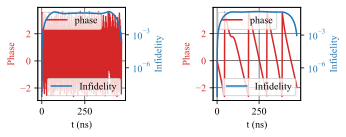

In [19]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            'pickles/mesolve_12_reference_states_two_level_sesolve.pkl'
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        # infidelity = []
        # phase = []
        # for idx in tqdm(range(num_time_steps), desc='Processing'):
        #     dms = [result.states[idx] for result in results]
        #     def objective_function(phase):
        #         return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
        #     initial_phase = [0.0]
        #     bounds = [(0, 2 * 3.141592653589793)]
        #     opt_result = minimize(objective_function, initial_phase,method="COBYLA")
        #     infidelity.append(opt_result.fun)
        #     phase.append(opt_result.x[0])
        # with open(f'pickles/sesolve_reference_states_{i}{j}_(infidelity,phase).pkl', 'wb') as file:
        #     pickle.dump((infidelity,phase), file)

        
        with open(f'pickles/sesolve_reference_states_{i}{j}_(infidelity,phase).pkl', 'rb') as file:
            infidelity,phase = pickle.load(file)
        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()